# Webscraping ile ev kira fiyatları tahmini

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("house_data.csv")
pd.set_option('display.max_columns', None)

In [3]:
df

,İlan Numarası,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Fiyat Durumu,Ada,Parsel,Fiyat,Location,İlan linki,Eşya Durumu,Takas,Depozito,Balkon Durumu,Balkon Sayısı,Balkon Tipi,Aidat,WC Sayısı,Yapı Durumu,Yapı Tipi,Banyo Metrekare,Balkon Metrekare,Görüntülü Gezilebilir mi?,Enerji Kimlik Belgesi,Salon Metrekare,WC Metrekare
0,19422809,30 Mayıs 2026,Konut,Kiralık,Daire,110 m²,155 m²,3+1,3,2.Kat,5,Merkezi (Pay Ölçer),Boş,Kat Mülkiyeti,Hayır,1,Genel Fiyat,30734.0,3.0,28.000TL,Konya - Karatay,https://www.emlakjet.com/ilan/karaca-dan-erenl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19422509,30 Mayıs 2026,Konut,Kiralık,Daire,130 m²,155 m²,3+1,21 Ve Üzeri,2.Kat,4,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,Genel Fiyat,NaN,NaN,18.000TL,Konya - Selçuklu,https://www.emlakjet.com/ilan/isiklar-mah-yege...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19421287,29 Mayıs 2026,Konut,Kiralık,Daire,145 m²,165 m²,3+1,16-20,6.Kat,6,Merkezi Doğalgaz,Boş,Kat Mülkiyeti,Evet,2,Genel Fiyat,NaN,NaN,23.000TL,Konya - Karatay,https://www.emlakjet.com/ilan/babi-emlaktan-ki...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19421112,29 Mayıs 2026,Konut,Kiralık,Daire,145 m²,180 m²,3+1,11-15,4.Kat,4,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Evet,1,Genel Fiyat,NaN,NaN,25.000TL,Konya - Akşehir,https://www.emlakjet.com/ilan/zirve-emlak-kira...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19421074,29 Mayıs 2026,Konut,Kiralık,Daire,90 m²,100 m²,2+1,3,3.Kat,5,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,Genel Fiyat,NaN,NaN,24.000TL,Konya - Karatay,https://www.emlakjet.com/ilan/kucukkum-kopru-c...,Boş,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,15484289,25 Mayıs 2026,Konut,Kiralık,Daire,70 m²,89 m²,2+1,0 (Yeni),1.Kat,4,Merkezi (Pay Ölçer),Boş,Tapu Kaydı Yok,Hayır,1,Genel Fiyat,NaN,NaN,24.000TL,Konya - Selçuklu,https://www.emlakjet.com/ilan/konsey-den-ardic...,Eşyalı,Yok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471,14949061,22 Mayıs 2026,Konut,Kiralık,Daire,135 m²,145 m²,3+1,21 Ve Üzeri,2.Kat,3,Kombi Doğalgaz,Boş,Arsa Tapulu,Hayır,1,Genel Fiyat,NaN,NaN,14.000TL,Konya - Seydişehir,https://www.emlakjet.com/ilan/esyali-kiralik-d...,Eşyalı,NaN,NaN,Var,2.0,Açık Teras,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
472,14829824,27 Mayıs 2026,Konut,Kiralık,Daire,140 m²,145 m²,3+1,21 Ve Üzeri,2.Kat,3,Kombi Doğalgaz,Boş,Kat İrtifakı,Hayır,1,Genel Fiyat,NaN,NaN,27.000TL,Konya - Akşehir,https://www.emlakjet.com/ilan/asil-emlaktan-ki...,Eşyalı,Yok,27500 TL,Var,2.0,"Açık Balkon, Kapalı Balkon",200 TL,2.0,İkinci El,Yığma,NaN,NaN,Evet,NaN,NaN,NaN
473,10171744,30 Mayıs 2026,Konut,Kiralık,Daire,130 m²,150 m²,3+1,21 Ve Üzeri,3.Kat,5,Merkezi Doğalgaz,Boş,Kat Mülkiyeti,Evet,1,Genel Fiyat,15128.0,9.0,22.000TL,Konya - Selçuklu,https://www.emlakjet.com/ilan/musalla-baglari-...,NaN,NaN,NaN,Var,2.0,Kapalı Balkon,400 TL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:

drop_cols = [
    "İlan Numarası",
    "İlan linki",
    "Ada",
    "Parsel"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [5]:
for col in df.columns:
    print(col, (df[col]==0).mean()*100)

İlan Güncelleme Tarihi 0.0
Türü 0.0
Kategorisi 0.0
Tipi 0.0
Net Metrekare 0.0
Brüt Metrekare 0.0
Oda Sayısı 0.0
Binanın Yaşı 0.0
Bulunduğu Kat 0.0
Binanın Kat Sayısı 0.0
Isıtma Tipi 0.0
Kullanım Durumu 0.0
Tapu Durumu 0.0
Site İçerisinde 0.0
Banyo Sayısı 0.0
Fiyat Durumu 0.0
Fiyat 0.0
Location 0.0
Eşya Durumu 0.0
Takas 0.0
Depozito 0.0
Balkon Durumu 0.0
Balkon Sayısı 0.0
Balkon Tipi 0.0
Aidat 0.0
WC Sayısı 0.0
Yapı Durumu 0.0
Yapı Tipi 0.0
Banyo Metrekare 0.0
Balkon Metrekare 0.0
Görüntülü Gezilebilir mi? 0.0
Enerji Kimlik Belgesi 0.0
Salon Metrekare 0.0
WC Metrekare 0.0


In [6]:
df["Fiyat"].describe()

count          475
unique          77
top       20.000TL
freq            50
Name: Fiyat, dtype: object

In [7]:
df.shape

(475, 34)

In [8]:
df["Fiyat"] = (
    df["Fiyat"]
    .astype(str)
    .str.replace("TL","", regex=False)
    .str.replace(".","", regex=False)
)

df["Fiyat"] = pd.to_numeric(df["Fiyat"], errors="coerce")

In [9]:
df = df[df["Fiyat"] < 100000]

In [10]:
df["Net Metrekare"] = (
    df["Net Metrekare"]
    .astype(str)
    .str.replace("m²","", regex=False)
    .str.strip()
)

df["Net Metrekare"] = pd.to_numeric(
    df["Net Metrekare"],
    errors="coerce"
)

In [11]:
df["Brüt Metrekare"] = (
    df["Brüt Metrekare"]
    .astype(str)
    .str.replace("m²","", regex=False)
    .str.strip()
)

df["Brüt Metrekare"] = pd.to_numeric(
    df["Brüt Metrekare"],
    errors="coerce"
)

In [12]:
def convert_room(x):

    try:
        parts = str(x).split("+")
        return int(parts[0]) + int(parts[1])

    except:
        return 0

df["Oda Sayısı"] = df["Oda Sayısı"].apply(convert_room)

In [13]:
def convert_age(x):

    x = str(x)

    if "Yeni" in x:
        return 0

    elif "11-15" in x:
        return 13

    elif "16-20" in x:
        return 18

    elif "21" in x:
        return 25

    else:
        try:
            return int(x)
        except:
            return 0

df["Binanın Yaşı"] = df["Binanın Yaşı"].apply(convert_age)

In [14]:
df["Aidat"] = (df["Aidat"].astype(str).str.replace("TL","", regex=False).str.replace(".","", regex=False))

df["Aidat"] = pd.to_numeric(df["Aidat"],errors="coerce").fillna(0)

In [15]:
df["Depozito"] = (
    df["Depozito"]
    .astype(str)
    .str.replace("TL","", regex=False)
    .str.replace(".","", regex=False)
)

df["Depozito"] = pd.to_numeric(
    df["Depozito"],
    errors="coerce"
).fillna(0)

In [16]:
df["Bulunduğu Kat"] = (
    df["Bulunduğu Kat"]
    .astype(str)
    .str.replace("Kat","", regex=False)
    .str.replace(".","", regex=False)
)

df["Bulunduğu Kat"] = pd.to_numeric(
    df["Bulunduğu Kat"],
    errors="coerce"
).fillna(0)

In [17]:
df.describe()

,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Fiyat,Depozito,Balkon Sayısı,Aidat,WC Sayısı
count,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,60.000000,473.000000,42.000000
mean,110.016913,130.663848,3.418605,11.600423,2.723044,5.099366,22087.207188,2102.536998,1.766667,180.412262,1.547619
std,36.228321,44.070330,1.015887,10.139230,2.186592,2.473731,8013.879022,6860.485751,0.697858,526.298223,0.592736
min,20.000000,30.000000,0.000000,0.000000,0.000000,1.000000,5750.000000,0.000000,1.000000,0.000000,1.000000
25%,85.000000,100.000000,3.000000,0.000000,1.000000,3.000000,18000.000000,0.000000,1.000000,0.000000,1.000000
50%,115.000000,130.000000,4.000000,13.000000,2.000000,5.000000,20500.000000,0.000000,2.000000,0.000000,1.500000
75%,135.000000,155.000000,4.000000,25.000000,4.000000,6.000000,25000.000000,0.000000,2.000000,0.000000,2.000000
max,220.000000,500.000000,7.000000,25.000000,13.000000,16.000000,70000.000000,50000.000000,3.000000,4750.000000,3.000000


In [18]:
df.isnull().sum()

İlan Güncelleme Tarihi         0
Türü                           0
Kategorisi                     0
Tipi                           0
Net Metrekare                  0
Brüt Metrekare                 0
Oda Sayısı                     0
Binanın Yaşı                   0
Bulunduğu Kat                  0
Binanın Kat Sayısı             0
Isıtma Tipi                    0
Kullanım Durumu                0
Tapu Durumu                    0
Site İçerisinde                0
Banyo Sayısı                   0
Fiyat Durumu                   0
Fiyat                          0
Location                       0
Eşya Durumu                  278
Takas                        162
Depozito                       0
Balkon Durumu                403
Balkon Sayısı                413
Balkon Tipi                  427
Aidat                          0
WC Sayısı                    431
Yapı Durumu                  436
Yapı Tipi                    438
Banyo Metrekare              454
Balkon Metrekare             450
Görüntülü 

In [19]:
df.corr(numeric_only=True)

,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Fiyat,Depozito,Balkon Sayısı,Aidat,WC Sayısı
Net Metrekare,1.000000,0.909122,0.764108,0.219884,0.286230,0.305015,0.459530,0.080734,0.529763,0.071182,0.586667
Brüt Metrekare,0.909122,1.000000,0.738586,0.139433,0.263214,0.264491,0.465625,0.050546,0.505926,0.060235,0.616490
Oda Sayısı,0.764108,0.738586,1.000000,0.191930,0.244964,0.184062,0.355610,-0.000244,0.418315,0.055549,0.253786
Binanın Yaşı,0.219884,0.139433,0.191930,1.000000,0.102027,-0.013618,-0.317086,-0.011791,0.311766,-0.065425,0.077652
Bulunduğu Kat,0.286230,0.263214,0.244964,0.102027,1.000000,0.562076,0.247794,0.112200,0.247861,0.217699,0.108794
Binanın Kat Sayısı,0.305015,0.264491,0.184062,-0.013618,0.562076,1.000000,0.389323,0.026239,-0.012045,0.288167,-0.133199
Fiyat,0.459530,0.465625,0.355610,-0.317086,0.247794,0.389323,1.000000,0.078815,-0.029330,0.237524,-0.021910
Depozito,0.080734,0.050546,-0.000244,-0.011791,0.112200,0.026239,0.078815,1.000000,-0.083979,0.234397,0.043603
Balkon Sayısı,0.529763,0.505926,0.418315,0.311766,0.247861,-0.012045,-0.029330,-0.083979,1.000000,-0.119735,0.326162
Aidat,0.071182,0.060235,0.055549,-0.065425,0.217699,0.288167,0.237524,0.234397,-0.119735,1.000000,-0.269395


<Axes: >

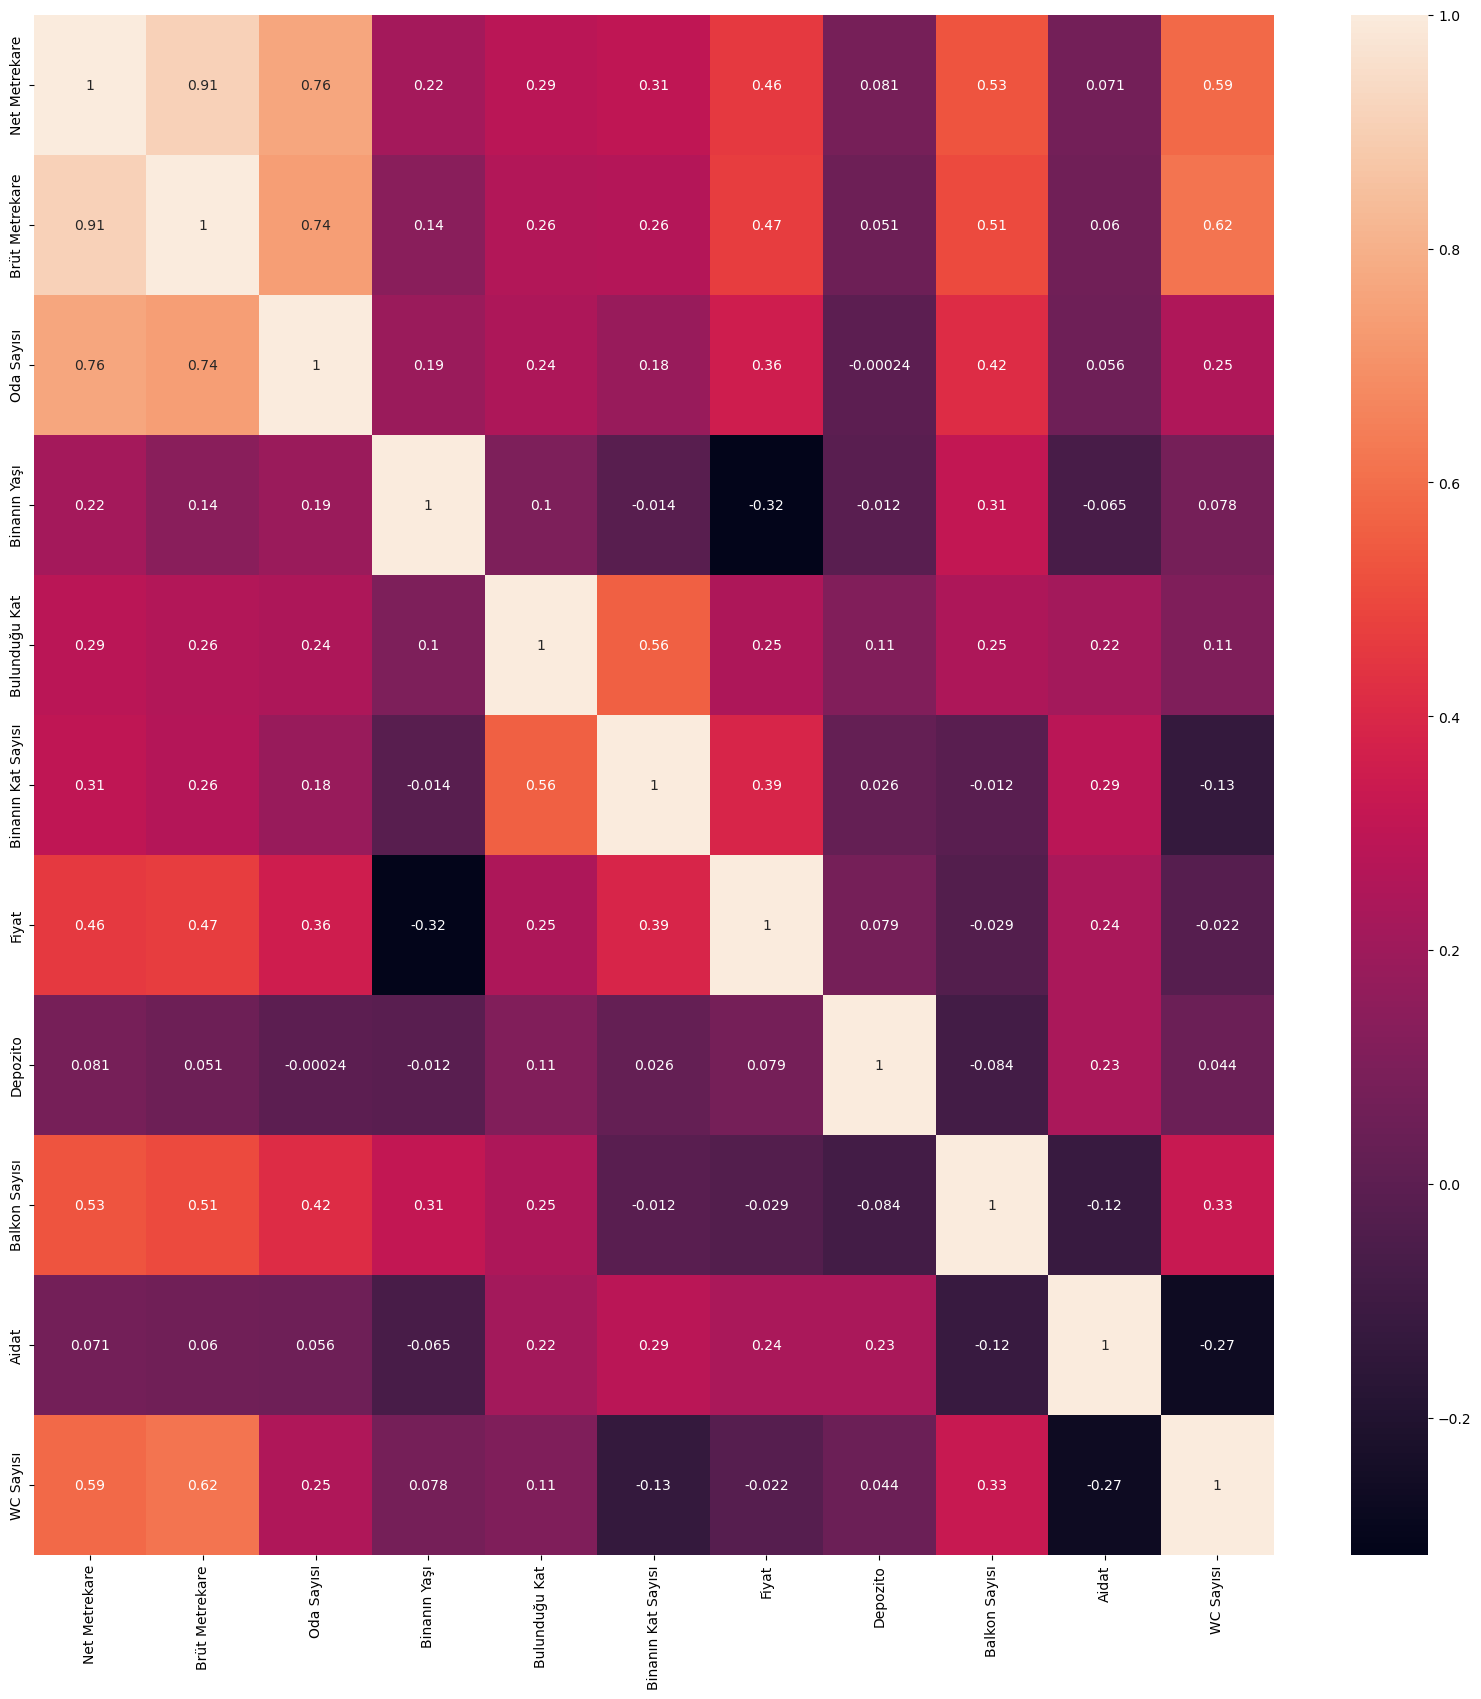

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [21]:
abs(df.corr(numeric_only=True) ['Fiyat'].sort_values(ascending=False))

Fiyat                 1.000000
Brüt Metrekare        0.465625
Net Metrekare         0.459530
Binanın Kat Sayısı    0.389323
Oda Sayısı            0.355610
Bulunduğu Kat         0.247794
Aidat                 0.237524
Depozito              0.078815
WC Sayısı             0.021910
Balkon Sayısı         0.029330
Binanın Yaşı          0.317086
Name: Fiyat, dtype: float64

<Axes: xlabel='Oda Sayısı'>

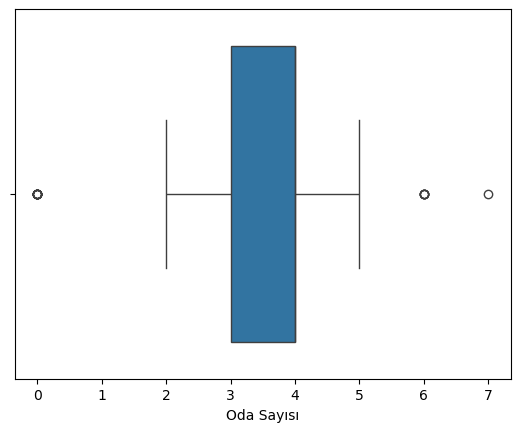

In [22]:
sns.boxplot(x=df['Oda Sayısı'])

In [23]:
df['Oda Sayısı'].mean()+3*df['Oda Sayısı'].std()

np.float64(6.466265087432702)

In [24]:
df[df['Oda Sayısı']>30]

,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Fiyat Durumu,Fiyat,Location,Eşya Durumu,Takas,Depozito,Balkon Durumu,Balkon Sayısı,Balkon Tipi,Aidat,WC Sayısı,Yapı Durumu,Yapı Tipi,Banyo Metrekare,Balkon Metrekare,Görüntülü Gezilebilir mi?,Enerji Kimlik Belgesi,Salon Metrekare,WC Metrekare


<Axes: xlabel='Net Metrekare'>

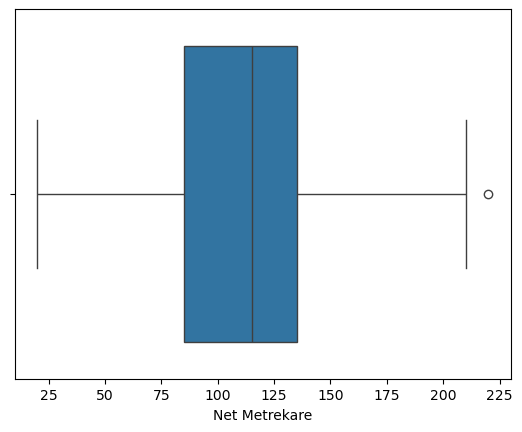

In [25]:
sns.boxplot(x=df['Net Metrekare'])

<Axes: xlabel='Banyo Sayısı', ylabel='count'>

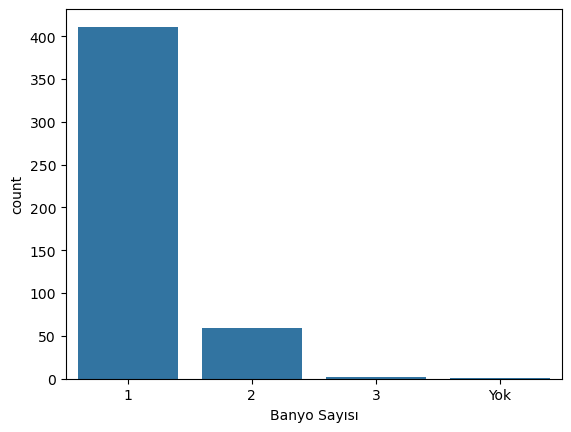

In [26]:
sns.countplot(x=df['Banyo Sayısı'])

In [27]:
outliers=df.quantile(q=.97,numeric_only=True)

In [28]:
df=df[(df['Fiyat']<outliers['Fiyat'])]
df=df[(df['Oda Sayısı']<outliers['Oda Sayısı'])]
df=df[(df['WC Sayısı']<outliers['WC Sayısı'])]
df=df[(df['Net Metrekare']<outliers['Net Metrekare'])]

<Axes: xlabel='WC Sayısı', ylabel='count'>

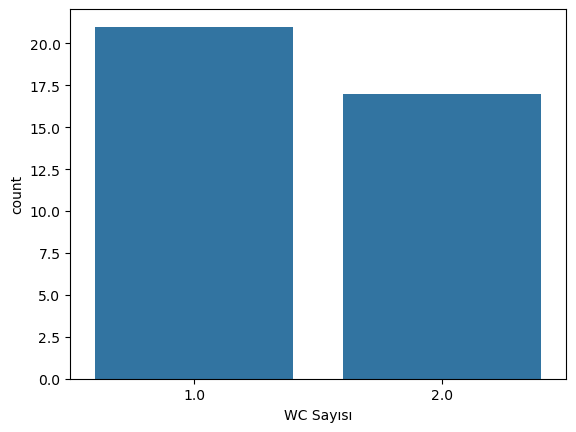

In [29]:
sns.countplot(x=df['WC Sayısı'])

In [30]:
df

,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Fiyat Durumu,Fiyat,Location,Eşya Durumu,Takas,Depozito,Balkon Durumu,Balkon Sayısı,Balkon Tipi,Aidat,WC Sayısı,Yapı Durumu,Yapı Tipi,Banyo Metrekare,Balkon Metrekare,Görüntülü Gezilebilir mi?,Enerji Kimlik Belgesi,Salon Metrekare,WC Metrekare
15,26 Mayıs 2026,Konut,Kiralık,Daire,49,50,0,13,7.0,7,Merkezi (Pay Ölçer),Kiracı Oturuyor,Kat Mülkiyeti,Hayır,1,Genel Fiyat,10000,Konya - Selçuklu,Eşyalı,NaN,0.0,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,24 Mayıs 2026,Konut,Kiralık,Daire,120,130,4,25,2.0,3,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,Birim Fiyat,18000,Konya - Selçuklu,Boş,Yok,0.0,Var,2.0,Açık Balkon,50.0,2.0,İkinci El,Betonarme,3 m²,6 m²,Hayır,Yok,NaN,NaN
21,25 Mayıs 2026,Konut,Kiralık,Daire,55,75,2,0,3.0,3,Kombi Doğalgaz,Kiracı Oturuyor,Kat Mülkiyeti,Evet,1,Birim Fiyat,20000,Konya - Selçuklu,Eşyalı,Yok,20000.0,Var,1.0,Açık Balkon,1000.0,1.0,İkinci El,Betonarme,NaN,NaN,NaN,C Sınıfı,NaN,NaN
30,29 Mayıs 2026,Konut,Kiralık,Daire,80,100,3,3,1.0,4,Merkezi (Pay Ölçer),Boş,Kat Mülkiyeti,Evet,1,Genel Fiyat,24000,Konya - Selçuklu,Eşyalı,Yok,0.0,Var,1.0,Kapalı Balkon,1100.0,1.0,İkinci El,Betonarme,8 m²,6 m²,Hayır,NaN,20 m²,6 m²
79,30 Mayıs 2026,Konut,Kiralık,Daire,110,125,3,25,3.0,4,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Evet,1,Genel Fiyat,13500,Konya - Akşehir,Boş,Yok,0.0,Var,3.0,"Açık Balkon, Kapalı Balkon",150.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,29 Mayıs 2026,Konut,Kiralık,Daire,130,150,4,0,4.0,8,Merkezi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,Genel Fiyat,25000,Konya - Selçuklu,Boş,NaN,0.0,Var,1.0,Açık Balkon,1350.0,1.0,İkinci El,Betonarme,8 m²,8 m²,Hayır,NaN,26 m²,6 m²
92,26 Mayıs 2026,Konut,Kiralık,Daire,135,150,4,18,0.0,3,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,Genel Fiyat,20000,Konya - Karatay,Boş,Yok,20000.0,Var,2.0,Açık Balkon,500.0,1.0,İkinci El,Betonarme,5 m²,5 m²,Evet,NaN,30 m²,5 m²
106,15 Mayıs 2026,Konut,Kiralık,Daire,130,150,4,2,4.0,4,Merkezi Doğalgaz,Boş,Müstakil Tapulu,Hayır,1,Genel Fiyat,19000,Konya - Seydişehir,Boş,Yok,0.0,Var,1.0,Kapalı Balkon,250.0,2.0,İkinci El,Betonarme,5 m²,5 m²,NaN,B Sınıfı,30 m²,3 m²
115,21 Mayıs 2026,Konut,Kiralık,Daire,120,140,4,18,2.0,6,Merkezi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,Genel Fiyat,22000,Konya - Meram,NaN,NaN,0.0,Var,2.0,NaN,800.0,2.0,İkinci El,Betonarme,NaN,NaN,NaN,NaN,NaN,NaN
125,25 Mayıs 2026,Konut,Kiralık,Daire,55,75,2,13,2.0,8,Merkezi (Pay Ölçer),Kiracı Oturuyor,Kat Mülkiyeti,Evet,1,Birim Fiyat,20000,Konya - Selçuklu,NaN,Yok,0.0,Var,1.0,Açık Balkon,0.0,1.0,İkinci El,Betonarme,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
cat_cols = df.select_dtypes(include=['object']).columns

In [32]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [33]:
df = df_encoded.dropna()

In [34]:
df

,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Fiyat,Depozito,Balkon Sayısı,Aidat,WC Sayısı,İlan Güncelleme Tarihi_05 Mayıs 2026,İlan Güncelleme Tarihi_07 Mayıs 2026,İlan Güncelleme Tarihi_15 Mayıs 2026,İlan Güncelleme Tarihi_16 Mayıs 2026,İlan Güncelleme Tarihi_17 Mayıs 2026,İlan Güncelleme Tarihi_21 Mayıs 2026,İlan Güncelleme Tarihi_22 Mayıs 2026,İlan Güncelleme Tarihi_24 Mayıs 2026,İlan Güncelleme Tarihi_25 Mayıs 2026,İlan Güncelleme Tarihi_26 Mayıs 2026,İlan Güncelleme Tarihi_27 Mayıs 2026,İlan Güncelleme Tarihi_29 Mayıs 2026,İlan Güncelleme Tarihi_30 Mayıs 2026,Isıtma Tipi_Merkezi (Pay Ölçer),Isıtma Tipi_Merkezi Doğalgaz,Isıtma Tipi_Sobalı,Isıtma Tipi_Yerden Isıtma,Kullanım Durumu_Kiracı Oturuyor,Tapu Durumu_Bilinmiyor,Tapu Durumu_Kat Mülkiyeti,Tapu Durumu_Kat İrtifakı,Tapu Durumu_Müstakil Tapulu,Tapu Durumu_Tapu Kaydı Yok,Site İçerisinde_Hayır,Banyo Sayısı_2,Fiyat Durumu_Genel Fiyat,Location_Konya - Beyşehir,Location_Konya - Ilgın,Location_Konya - Karatay,Location_Konya - Meram,Location_Konya - Selçuklu,Location_Konya - Seydişehir,Eşya Durumu_Eşyalı,Balkon Durumu_Yok,"Balkon Tipi_Açık Balkon, Kapalı Balkon",Balkon Tipi_Kapalı Balkon,Yapı Durumu_İkinci El,Yapı Tipi_Taş Bina,Yapı Tipi_Yığma,Banyo Metrekare_20 m²,Banyo Metrekare_3 m²,Banyo Metrekare_4 m²,Banyo Metrekare_5 m²,Banyo Metrekare_6 m²,Banyo Metrekare_7 m²,Banyo Metrekare_8 m²,Balkon Metrekare_15 m²,Balkon Metrekare_20 m²,Balkon Metrekare_5 m²,Balkon Metrekare_6 m²,Balkon Metrekare_8 m²,Balkon Metrekare_9 m²,Görüntülü Gezilebilir mi?_Hayır,Enerji Kimlik Belgesi_B Sınıfı,Enerji Kimlik Belgesi_C Sınıfı,Enerji Kimlik Belgesi_Yok,Salon Metrekare_20 m²,Salon Metrekare_22 m²,Salon Metrekare_25 m²,Salon Metrekare_26 m²,Salon Metrekare_28 m²,Salon Metrekare_30 m²,WC Metrekare_2 m²,WC Metrekare_3 m²,WC Metrekare_4 m²,WC Metrekare_5 m²,WC Metrekare_6 m²,WC Metrekare_9 m²
20,120,130,4,25,2.0,3,18000,0.0,2.0,50.0,2.0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
21,55,75,2,0,3.0,3,20000,20000.0,1.0,1000.0,1.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
30,80,100,3,3,1.0,4,24000,0.0,1.0,1100.0,1.0,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
79,110,125,3,25,3.0,4,13500,0.0,3.0,150.0,2.0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
80,130,150,4,0,4.0,8,25000,0.0,1.0,1350.0,1.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,F

In [35]:
X = df.drop("Fiyat", axis=1)

y = df["Fiyat"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [38]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lr=LinearRegression()

In [41]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
tahmin=lr.predict(X_test)

In [43]:
r2_score(y_test,tahmin)

-0.32936134439834497

In [44]:
mean_squared_error(y_test,tahmin)**.5

7981.279674193875

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [46]:
algo_test(X,y)

,R_Squared,RMSE,MAE
Decision Tree,7.987649e-01,3.105295e+03,2.714286e+03
Gradient Boosting,6.886595e-01,3.862503e+03,3.514820e+03
ElasticNet,6.483815e-01,4.104751e+03,3.540334e+03
KNeighborsRegressor,5.437944e-01,4.675535e+03,3.930125e+03
AdaBoost,5.369730e-01,4.710361e+03,3.935714e+03
Ridge,4.790543e-01,4.996286e+03,4.272176e+03
Linear,2.849180e-01,5.853679e+03,4.561069e+03
Extra Tree,5.046848e-02,6.745369e+03,5.000000e+03
SVR,-1.535052e-01,7.434654e+03,5.856552e+03
XGBRegressor,-2.548051e-01,7.754238e+03,5.986593e+03


In [47]:
df['Balkon Sayısı'].value_counts()

Balkon Sayısı
2.0    15
1.0    14
3.0     5
Name: count, dtype: int64

In [48]:
df['Balkon Sayısı'].value_counts(normalize=True)

Balkon Sayısı
2.0    0.441176
1.0    0.411765
3.0    0.147059
Name: proportion, dtype: float64

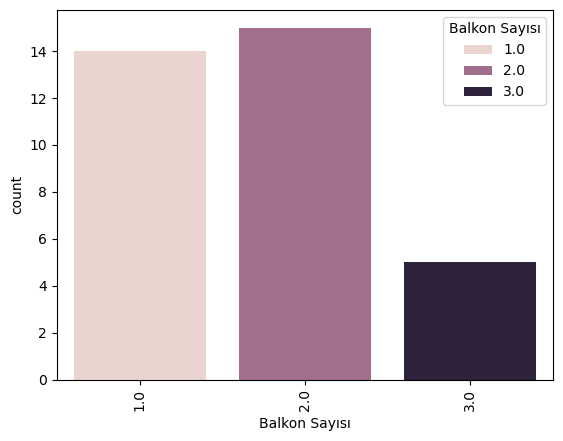

In [49]:
sns.countplot(x=df['Balkon Sayısı'],hue=df[ 'Balkon Sayısı']);
plt.xticks(rotation=90);

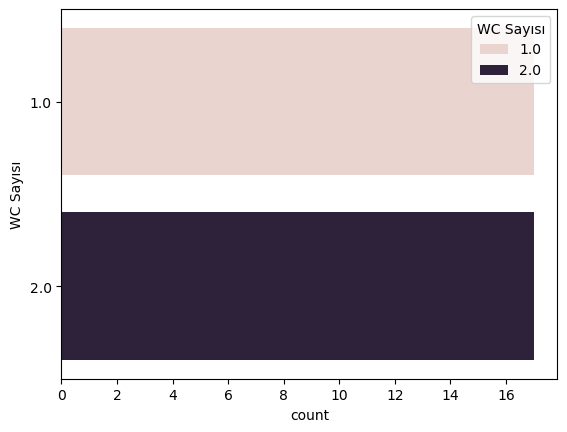

In [50]:
sns.countplot(y=df[ 'WC Sayısı'],hue=df[ 'WC Sayısı']);

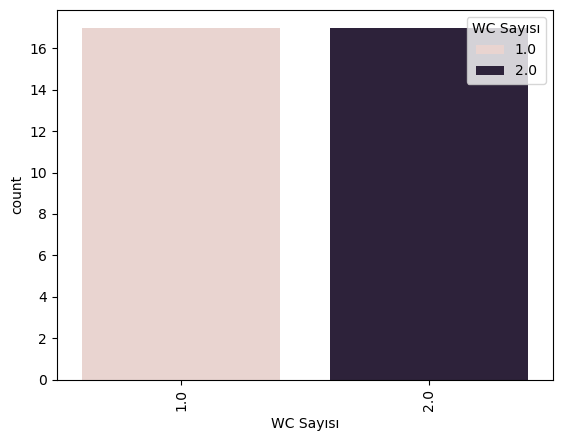

In [51]:
sns.countplot(x=df['WC Sayısı'],hue=df['WC Sayısı']);
plt.xticks(rotation=90);

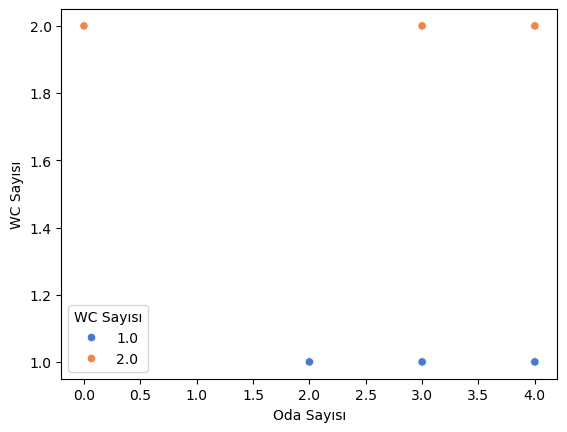

In [52]:
sns.scatterplot(x=df['Oda Sayısı'],y=df['WC Sayısı'],hue=df['WC Sayısı'],palette='muted'); 

In [53]:
residuals=y_test-tahmin

<Axes: xlabel='Fiyat', ylabel='Density'>

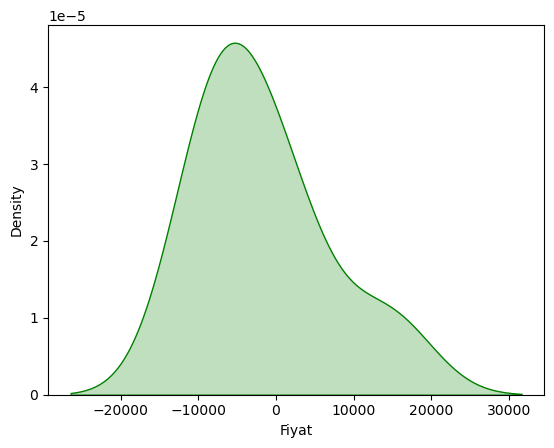

In [54]:
sns.kdeplot(x=residuals, fill=True, color='green')

In [55]:
import plotly.express as px

In [56]:
px.sunburst(df, path=['Oda Sayısı', 'WC Sayısı', 'Net Metrekare'],values='Fiyat')

In [57]:
from sklearn.tree import DecisionTreeRegressor
from yellowbrick.regressor import ResidualsPlot

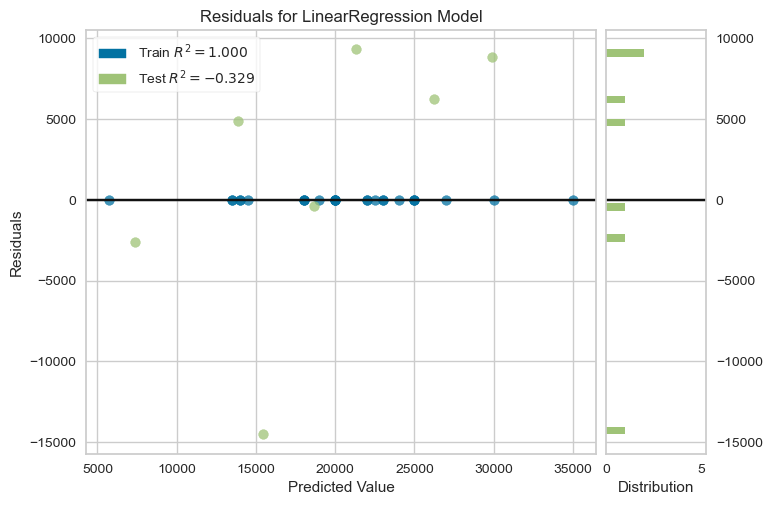

In [58]:
vis=ResidualsPlot(lr)
vis.fit(X_train,y_train)
vis.score(X_test,y_test)
vis.show()
plt.show()

In [59]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [60]:
model = Sequential([
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2), # Overfitting'i engellemek için %20 nöron kapatma
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error', 
              metrics=['mean_absolute_error'])

In [61]:
early_stop = EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)

In [62]:
history = model.fit(X_train, y_train,validation_split=0.2,epochs=100,batch_size=32,callbacks=[early_stop],verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 435114912.0000 - mean_absolute_error: 20036.1465 - val_loss: 505507840.0000 - val_mean_absolute_error: 21833.5371
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 435115456.0000 - mean_absolute_error: 20036.1152 - val_loss: 505507040.0000 - val_mean_absolute_error: 21833.5176
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - loss: 435109600.0000 - mean_absolute_error: 20036.1016 - val_loss: 505506080.0000 - val_mean_absolute_error: 21833.4961
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 435111168.0000 - mean_absolute_error: 20036.1289 - val_loss: 505505120.0000 - val_mean_absolute_error: 21833.4727
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 435096960.0000 - mean_absolute_error: 20035.8105 - val_loss: 505504352.0000 - val_mean_absolute_error: 21833.4551
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 435096192.0000 - mean_absolute_error: 20035.7344 - val_loss: 505503456.0000 - v

In [63]:
pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


In [64]:
mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 17281.55078125
RMSE: 18616.107434154972
R2  : -6.232288360595703


In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators=300,random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(
    "RF R2:",
    r2_score(y_test, pred_rf)
)

RF R2: 0.5557814579192695


In [66]:
model.save("KONYA__deep_model.h5")

In [67]:
model.save("KONYA_model.h5")

In [68]:
model.save("KONYA_model.keras")

In [71]:
import joblib

In [72]:
joblib.dump(scaler, 'konya_kira_scaler.pkl')

['konya_kira_scaler.pkl']